# BANA7046 Data Mining Final Exam - Jessie Reynolds
#### Palmer Penquins EDA and Prediction

#### Load Required Libraries

In [2]:
# Load required libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score
)

**Load Palmer Penquins**

In [3]:
# Load Palmer Penguins
penguins = sns.load_dataset("penguins")

**Show how many missing values there are in each column**

In [5]:
# Count the number of missing values in each column
missing_values = penguins.isnull().sum()
print(missing_values)

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


**Create Paired Plot** <br>
Notice the scale of the variables (range)

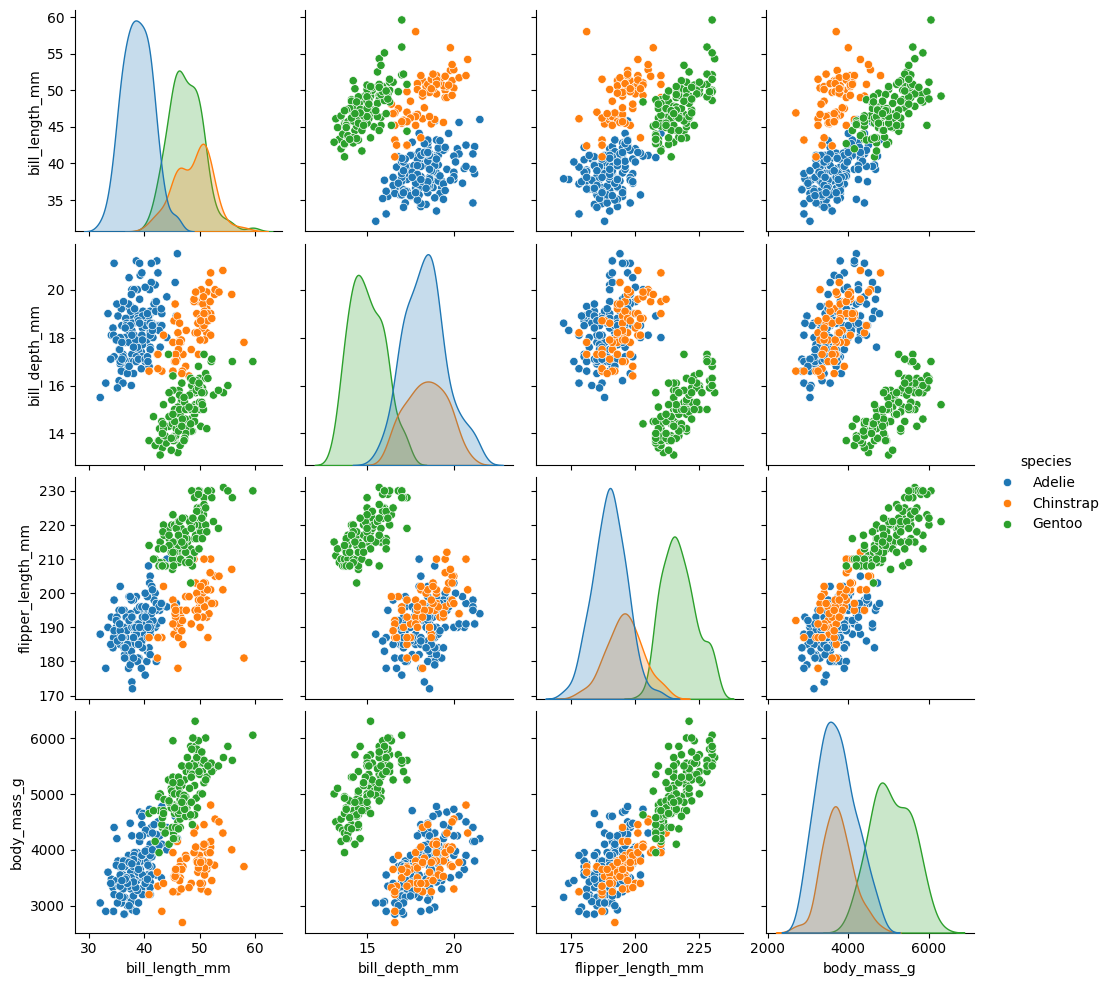

In [6]:
#Create paired plot to visualize relationships between features
sns.pairplot(penguins, hue="species")
plt.show()

**Calculate 5-Number Summary** <br>
Notice the scale of the variables (range)

In [7]:
#Calculate five number summary for each numeric feature
numeric_features = penguins.select_dtypes(include=[np.number])
five_number_summary = numeric_features.describe().loc[["min", "25%", "50%", "75%", "max"]]
print(five_number_summary)

     bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
min          32.100           13.1              172.0       2700.0
25%          39.225           15.6              190.0       3550.0
50%          44.450           17.3              197.0       4050.0
75%          48.500           18.7              213.0       4750.0
max          59.600           21.5              231.0       6300.0


**Plot boxplots with stripplot with jitter for each feature by species colored by species** <br>

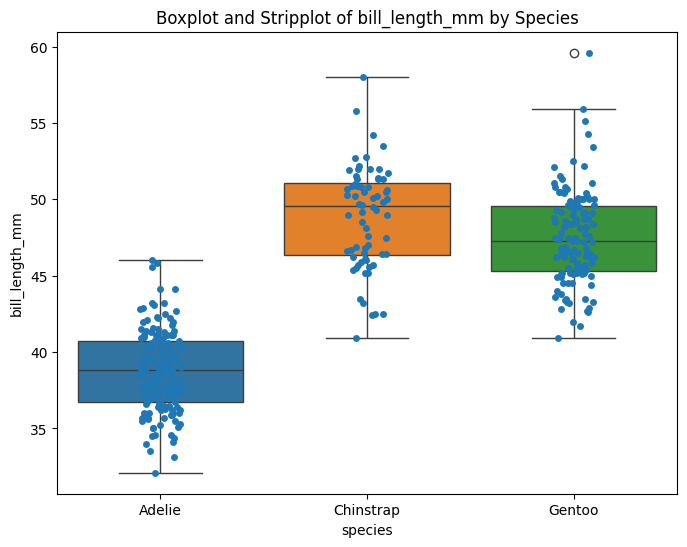

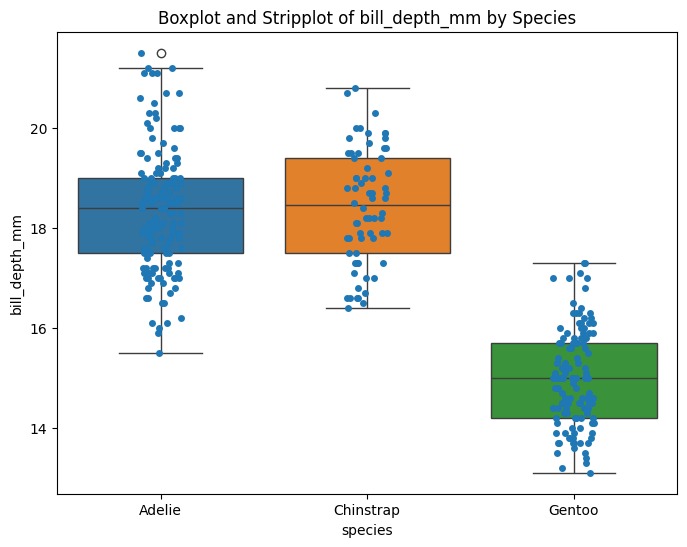

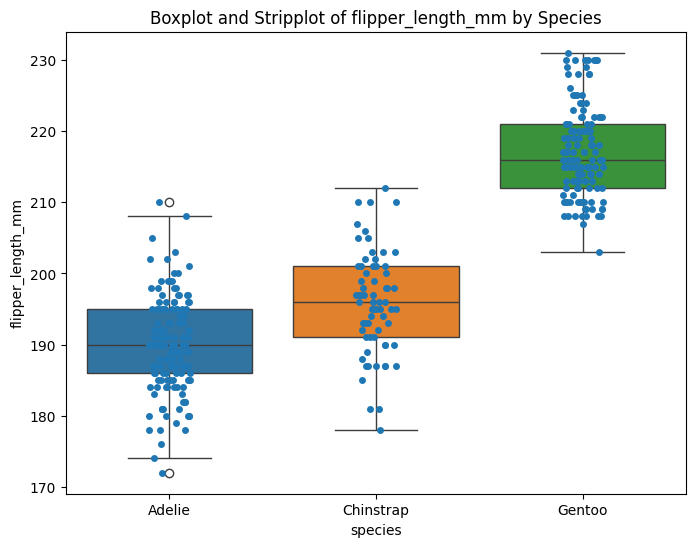

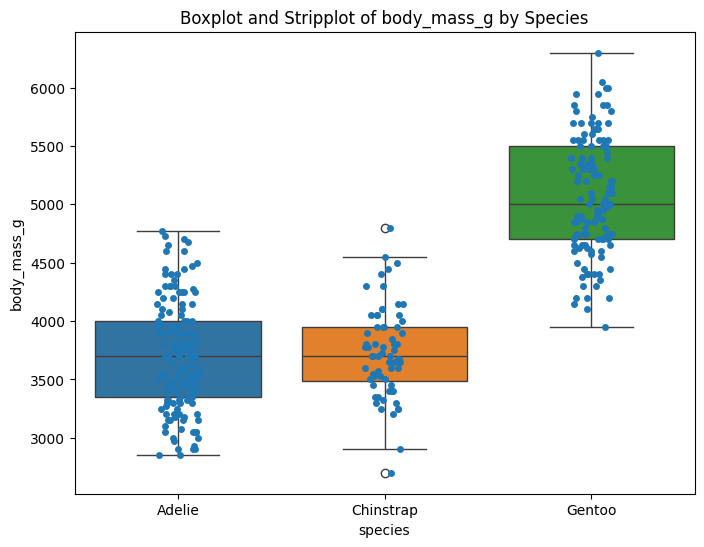

In [8]:
# Create boxplots with stripplot with jitter for each feature by species colored by species
for feature in numeric_features.columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x="species", y=feature, data=penguins, hue="species")
    sns.stripplot(x="species", y=feature, data=penguins, jitter=True, size=5)
    plt.title(f"Boxplot and Stripplot of {feature} by Species")
    plt.show()

**Calculate how many Gentoo penguins are outliers in bill_length_mm using the 1.5 × IQR rule**

In [9]:
#Calculate how many Gentoo penguins are outliers in bill_length_mm using the 1.5 × IQR rule
Q1 = penguins[penguins["species"] == "Gentoo"]["bill_length_mm"].quantile(0.25)
Q3 = penguins[penguins["species"] == "Gentoo"]["bill_length_mm"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = penguins[(penguins["species"] == "Gentoo") & ((penguins["bill_length_mm"] < lower_bound) | (penguins["bill_length_mm"] > upper_bound))]
num_outliers = outliers.shape[0]
print(f"Number of Gentoo penguins that are outliers in bill_length_mm: {num_outliers}") 

Number of Gentoo penguins that are outliers in bill_length_mm: 1


## Predict Sex (Male vs. Female)

### Logistic Regression

Predict penguin sex (Male vs Female) using logistic regression with the predictors: bill_length_mm, bill_depth_mm, flipper_length_mm, and body_mass_g.

In [ ]:
# 1. Prepare the dataset for modeling.
#    Remove any observations that cannot be used for training.
# 2. Ensure the target variable is in a format suitable for modeling.
# 3. Separate the predictors from the outcome variable.
# 4. Split the data into training and testing sets
#    (random_state=42) and 20% test size.
#    Apply any necessary transformations using only the training data.
# 5. Train model.
#    Perform 1,000 trial iterations.
# 6. Evaluate model performance on the test set.
# 7. Summarize performance using a confusion matrix and relevant metrics.

In [10]:
#Remove missing values
penguins_clean_lr = penguins.dropna() 

#remove species and island variables since they are not numeric and cannot be used in the model
penguins_clean_lr = penguins_clean_lr.drop(columns=["species", "island"])
penguins_clean_lr

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,Male
1,39.5,17.4,186.0,3800.0,Female
2,40.3,18.0,195.0,3250.0,Female
4,36.7,19.3,193.0,3450.0,Female
5,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...
338,47.2,13.7,214.0,4925.0,Female
340,46.8,14.3,215.0,4850.0,Female
341,50.4,15.7,222.0,5750.0,Male
342,45.2,14.8,212.0,5200.0,Female


In [11]:
#check if sex variable is categorical
print(penguins_clean_lr["sex"].dtype)  

#make sex variable categorical
penguins_clean_lr["sex"] = (penguins_clean_lr["sex"] == "Male").astype(int)

object


In [12]:
#Separate the predictors from the outcome variable ("sex")
predictors = penguins_clean_lr.drop(columns=["sex"])
target = penguins_clean_lr["sex"]

In [13]:
#Split the data into training and testing sets (random_state=42) and 20% test size.
X_train, X_test, y_train, y_test = train_test_split(predictors, target, test_size=0.2, random_state=42)


In [14]:
#Apply any necessary transformations using only the training data only on numeric data
numeric_features = X_train.select_dtypes(include=[np.number]).columns
scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

In [15]:
#train the model with 1000 trial iterations using Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train) 

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [16]:
#evaluate model performance on the test set.
y_pred = model.predict(X_test)
print(y_pred)

[0 0 1 0 1 0 1 1 1 1 1 1 0 0 0 0 0 0 1 0 1 0 1 1 0 0 0 0 1 1 0 1 1 0 1 0 1
 0 0 0 0 0 0 0 0 0 1 1 1 0 0 1 0 0 1 1 0 1 1 1 1 1 0 1 1 1 0]


In [17]:
#Summarize performance using a confusion matrix and relevant metrics
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

print(classification_report(y_test, y_pred))


Confusion Matrix:
[[32  5]
 [ 3 27]]
              precision    recall  f1-score   support

           0       0.91      0.86      0.89        37
           1       0.84      0.90      0.87        30

    accuracy                           0.88        67
   macro avg       0.88      0.88      0.88        67
weighted avg       0.88      0.88      0.88        67



In [18]:
#overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy:.2f}")  


Overall Accuracy: 0.88


In [19]:
#confusion matrix for logistic regression model labeled with male and female
conf_matrix_df = pd.DataFrame(conf_matrix, index=["Actual Female", "Actual Male"], columns=["Predicted Female", "Predicted Male"])
print("Confusion Matrix with Labels:")
print(conf_matrix_df)

Confusion Matrix with Labels:
               Predicted Female  Predicted Male
Actual Female                32               5
Actual Male                   3              27


### CART

Predict penguin sex (Male vs Female) using CART with the predictors: bill_length_mm, bill_depth_mm, flipper_length_mm, and body_mass_g.

In [20]:
# 1. Prepare the dataset for modeling.
#    Select the relevant predictors and remove observations with missing values.
# 2. Separate the predictors (X) and the outcome variable (y).
# 3. Split the data into training and testing sets.
#    (random_state=42) and 20% test size.
# 4. Train a decision tree classifier on the training data.
#    (random_state=42) again.
# 5. Visualize the fitted decision tree.
# 6. Generate predictions on the test set.
# 7. Evaluate model performance using appropriate classification metrics.
# 8. Display the confusion matrix to summarize classification results and calculate accuracy.

In [21]:
#1. Prepare the dataset for modeling.
#Select the relevant predictors and remove observations with missing values.
penguins_clean_cart = penguins.dropna()

#remove species and island variables since they are not numeric and cannot be used in the model
penguins_clean_cart = penguins_clean_cart.drop(columns=["species", "island"])
penguins_clean_cart

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,Male
1,39.5,17.4,186.0,3800.0,Female
2,40.3,18.0,195.0,3250.0,Female
4,36.7,19.3,193.0,3450.0,Female
5,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...
338,47.2,13.7,214.0,4925.0,Female
340,46.8,14.3,215.0,4850.0,Female
341,50.4,15.7,222.0,5750.0,Male
342,45.2,14.8,212.0,5200.0,Female


In [22]:
#2. Searate the predictors (X) and the outcome variable (y).
X = penguins_clean_cart.drop(columns=["sex"])
y = penguins_clean_cart["sex"]   

In [23]:
#3. Split the data into training and testing sets (random_state=42) and 20% test size
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
#4. Train a decision tree classifier on the training data (random_state=42) again
cart = DecisionTreeClassifier(random_state=42)
cart.fit(X_train, y_train) 

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current


--- Regression tree (text view, first 4 levels) ---
|--- body_mass_g <= 3712.50
|   |--- bill_depth_mm <= 18.65
|   |   |--- bill_depth_mm <= 18.55
|   |   |   |--- bill_length_mm <= 48.30
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- bill_length_mm >  48.30
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- bill_depth_mm >  18.55
|   |   |   |--- body_mass_g <= 3525.00
|   |   |   |   |--- class: Female
|   |   |   |--- body_mass_g >  3525.00
|   |   |   |   |--- truncated branch of depth 2
|   |--- bill_depth_mm >  18.65
|   |   |--- bill_length_mm <= 38.95
|   |   |   |--- bill_depth_mm <= 19.40
|   |   |   |   |--- class: Female
|   |   |   |--- bill_depth_mm >  19.40
|   |   |   |   |--- class: Male
|   |   |--- bill_length_mm >  38.95
|   |   |   |--- body_mass_g <= 3537.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- body_mass_g >  3537.50
|   |   |   |   |--- class: Male
|--- body_mass_g >  3712.50
|   |--- bill_depth_mm <= 1

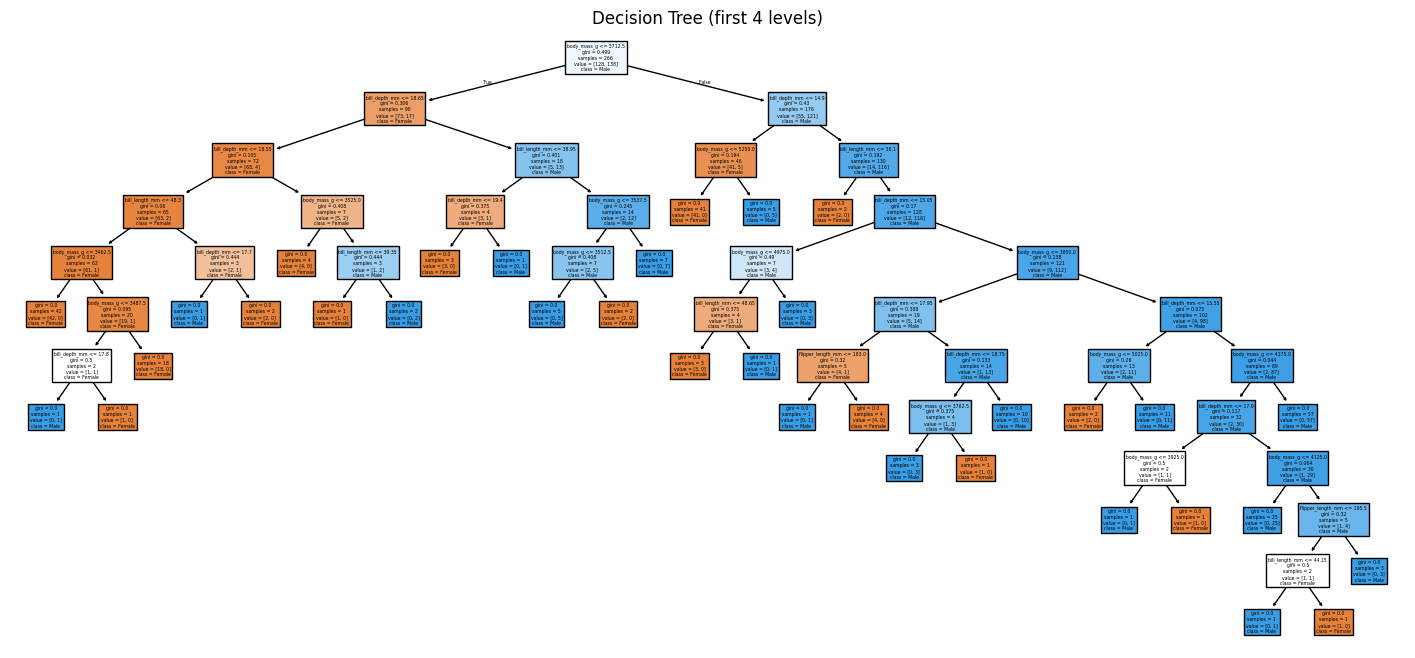

In [25]:
#5. Visualize the fitted decision tree
print("\n--- Regression tree (text view, first 4 levels) ---")
print(export_text(cart, feature_names=list(X.columns), max_depth=3))

plt.figure(figsize=(18, 8))
plot_tree(cart, filled=True, feature_names=X.columns, class_names=["Female", "Male"])
plt.title("Decision Tree (first 4 levels)")
plt.show()

In [26]:
#6. Generate predictions on the test set
y_pred = cart.predict(X_test) 
y_pred

array(['Female', 'Female', 'Male', 'Male', 'Male', 'Female', 'Male',
       'Male', 'Female', 'Male', 'Male', 'Female', 'Female', 'Female',
       'Female', 'Female', 'Female', 'Female', 'Male', 'Female', 'Male',
       'Female', 'Male', 'Male', 'Female', 'Female', 'Female', 'Female',
       'Female', 'Male', 'Female', 'Male', 'Male', 'Female', 'Male',
       'Female', 'Female', 'Female', 'Female', 'Female', 'Female',
       'Female', 'Female', 'Male', 'Female', 'Female', 'Male', 'Male',
       'Male', 'Female', 'Female', 'Male', 'Female', 'Female', 'Male',
       'Male', 'Female', 'Male', 'Male', 'Male', 'Male', 'Male', 'Female',
       'Female', 'Female', 'Male', 'Female'], dtype=object)

In [27]:
#7. Evaluate model performance using appropriate classification metrics
print(classification_report(y_test, y_pred))    

              precision    recall  f1-score   support

      Female       0.85      0.89      0.87        37
        Male       0.86      0.80      0.83        30

    accuracy                           0.85        67
   macro avg       0.85      0.85      0.85        67
weighted avg       0.85      0.85      0.85        67



In [28]:
#8. Display the confusion matrix to summarize classification results and calculate accuracy
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)  

[[33  4]
 [ 6 24]]


### K-Nearest Neighbor

Predict penguin sex (Male vs Female) using KNN with the predictors: bill_length_mm, bill_depth_mm, flipper_length_mm, and body_mass_g.

In [130]:
# 1. Prepare the dataset for modeling.
#    Select the relevant predictors and remove observations with missing values.
# 2. Separate the predictors (X) and the outcome variable (y).
# 3. Split the data into training and testing sets.
#    (random_state=42) and 20% test size.
# 4. Train a K-Nearest Neighbors (KNN) classifier on the training data.
#    Choose an appropriate value of k (number of neighbors).
# 5. Generate predictions on the test set.
# 6. Evaluate model performance using appropriate classification metrics.
# 7. Display the confusion matrix to summarize classification results.
# 8. Report overall accuracy and interpret the results.

Confusion Matrix:
[[32  5]
 [ 2 28]]


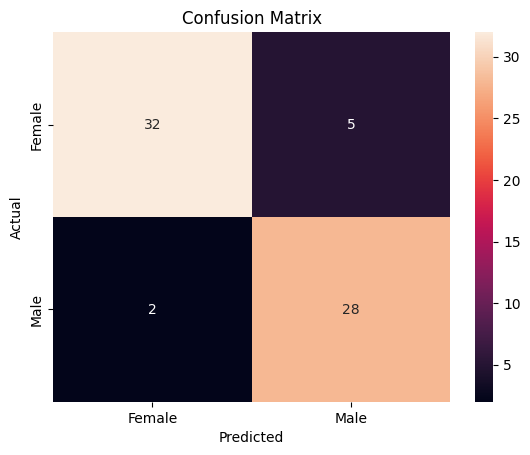


Classification Report:
              precision    recall  f1-score   support

      Female       0.94      0.86      0.90        37
        Male       0.85      0.93      0.89        30

    accuracy                           0.90        67
   macro avg       0.89      0.90      0.90        67
weighted avg       0.90      0.90      0.90        67

Overall Accuracy: 0.896


In [29]:
# 1. Load dataset and prepare for modeling
penguins = sns.load_dataset("penguins")
penguins = penguins[[
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
    "sex"
]].dropna()

# 2. Separate predictors (X) and outcome (y)
X = penguins[[
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]]

y = penguins["sex"]

# 3. Split into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

#. Scale the data (IMPORTANT for KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train KNN model (k = 5)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# 5. Generate predictions
y_pred = knn.predict(X_test_scaled)

# 6. Evaluate model
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# 7. Plot confusion matrix
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=knn.classes_,
            yticklabels=knn.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 8. Accuracy Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
print("Overall Accuracy: {:.3f}".format(accuracy))

### K-Fold Cross-Validation

5-fold CV on Logitic Regression

In [30]:
#5-fold cross validation to evaluate the model performance on logistic regression model
logreg = LogisticRegression(max_iter=1000)
cv = KFold(n_splits=5, shuffle=True, random_state=42)       
cv_scores = cross_val_score(logreg, X, y, cv=cv)
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean cross-validation score: {cv_scores.mean():.3f}")

Cross-validation scores: [0.91044776 0.92537313 0.92537313 0.89393939 0.87878788]
Mean cross-validation score: 0.907


5-fold CV on classification tree

In [31]:
#5 fold cross validation to evaluate the model performance on classification tree model
cart = DecisionTreeClassifier(random_state=42)
cv_scores_cart = cross_val_score(cart, X, y, cv=cv)
print(f"Cross-validation scores for Decision Tree: {cv_scores_cart}")
print(f"Mean cross-validation score for Decision Tree: {cv_scores_cart.mean():.3f}")    


Cross-validation scores for Decision Tree: [0.85074627 0.91044776 0.88059701 0.87878788 0.89393939]
Mean cross-validation score for Decision Tree: 0.883


5-fold CV on KNN

In [33]:
# 5 fold cross validation to evaluate the model performance on KNN model
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# Pipeline: scaling + KNN
knn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

# 5-fold CV (stratified keeps Male/Female balance similar in each fold)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Accuracy for each fold
cv_scores = cross_val_score(knn_pipe, X, y, cv=cv, scoring="accuracy")

print("5-fold CV accuracy scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())
print("Std CV accuracy:", cv_scores.std())

5-fold CV accuracy scores: [0.88059701 0.91044776 0.8358209  0.92424242 0.96969697]
Mean CV accuracy: 0.9041610131162369
Std CV accuracy: 0.044639403138134394


EXTRA CREDIT:<br>
Use 5-fold cross-validation to choose the value of k that gives the highest average accuracy.
(Loop through K to determine highest mean score)

In [34]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k_values = range(1, 21)
mean_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    
    scores = cross_val_score(knn, X_scaled, y, cv=5, scoring='accuracy')
    
    mean_scores.append(scores.mean())

# Find best k
best_k = k_values[np.argmax(mean_scores)]
best_score = max(mean_scores)

print("Best k:", best_k)
print("Highest average accuracy:", best_score)

Best k: 5
Highest average accuracy: 0.8828584350972412


In [ ]:
# Repeat with the best k value
knn_ec = KNeighborsClassifier(n_neighbors=best_k)
cv_scores_knn_best = cross_val_score(knn_ec, X_scaled, y, cv=5)
print("Cross-validation scores for best KNN model:", cv_scores_knn_best)
print("Mean CV score for best KNN model:", cv_scores_knn_best.mean())

Cross-validation scores for best KNN model: [0.89552239 0.91044776 0.85074627 0.86363636 0.89393939]
Mean CV score for best KNN model: 0.8828584350972412
